## Problem Statement

An e-commerce company tested a new experience (variant) against 
the existing one (control) to measure its impact on revenue.

- **Control:** existing experience  
- **Variant:** new experience  
- **Metric:** average revenue per user  
- **Goal:** determine whether the variant generates significantly 
  higher revenue than control

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, norm
from statsmodels.stats.proportion import proportions_ztest
import statsmodels.stats.proportion as smp
from statsmodels.stats.power import NormalIndPower

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

In [2]:
df = pd.read_csv("data/AB_Test_Results.csv")
df.head()

,USER_ID,VARIANT_NAME,REVENUE
0,737,variant,0.0
1,2423,control,0.0
2,9411,control,0.0
3,7311,control,0.0
4,6174,variant,0.0


In [3]:
df.shape

(10000, 3)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   USER_ID       10000 non-null  int64  
 1   VARIANT_NAME  10000 non-null  str    
 2   REVENUE       10000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 234.5 KB


In [5]:
df.columns = df.columns.str.lower()

In [6]:
df.columns

Index(['user_id', 'variant_name', 'revenue'], dtype='str')

In [7]:
df['variant_name'].value_counts()

variant_name
variant    5016
control    4984
Name: count, dtype: int64

In [8]:
df['revenue'].isnull().sum()

np.int64(0)

In [9]:
df.groupby('variant_name')['revenue'].mean()

variant_name
control    0.129013
variant    0.070070
Name: revenue, dtype: float64

## H0: mean_revenue_variant = mean_revenue_control → no difference
## H1:  revenue_variant ≠ revenue_control → difference exists (two-tailed)
## α = 0.05


In [10]:
group_a = df[df['variant_name'] == 'control']
group_b = df[df['variant_name'] == 'variant']

n_a = len(group_a)
n_b = len(group_b)

mean_a = group_a['revenue'].mean()
mean_b = group_b['revenue'].mean()

print(f"Group A (control) → n={n_a:,}  mean={mean_a:.4f}")
print(f"Group B (variant) → n={n_b:,}  mean={mean_b:.4f}")
print(f"Difference: {mean_b - mean_a:.4f}")

Group A (control) → n=4,984  mean=0.1290
Group B (variant) → n=5,016  mean=0.0701
Difference: -0.0589


In [11]:
values_a = group_a['revenue']
values_b = group_b['revenue']

t_stat, p_value_t = stats.ttest_ind(values_a, values_b)

print(f"T-statistic : {t_stat:.4f}")
print(f"P-value : {p_value_t:.4f}")

if p_value_t < 0.05:
    print("→ Reject H0. Means are significantly different.")
else:
    print("→ Fail to reject H0. Not enough evidence.")

T-statistic : 1.2712
P-value : 0.2037
→ Fail to reject H0. Not enough evidence.


## Statistical Test — Independent Samples T-Test

### Why T-Test?
The metric (`revenue`) is a continuous numerical variable, not binary (0/1).  
T-test compares the **means** of two independent groups to determine if the difference is statistically significant.

### Code
```python
values_a = group_a['revenue']
values_b = group_b['revenue']

t_stat, p_value_t = stats.ttest_ind(values_a, values_b)
```

`stats.ttest_ind()` takes two arrays of raw values and returns:
- **t_stat** — how many standard errors apart the two means are
- **p_value_t** — probability that this difference occurred by chance

### Results

| Metric | Value |
|---|---|
| T-statistic | 1.2712 |
| P-value | 0.2037 |
| Significance level (α) | 0.05 |
| Decision | **Fail to reject H0** |

### Interpretation
`p = 0.2037 > 0.05`

There is a 20.37% probability that the observed difference in means occurred by random chance. This is well above the 5% threshold, so we do not have sufficient evidence to conclude that the variant changed revenue.

The t-statistic of 1.27 tells us the two group means are only 1.27 standard errors apart — not far enough to be considered meaningful.

> **Business decision:** Do not ship the variant based on this test alone.  
> Consider running the test longer, increasing sample size, or testing a more impactful change.

In [12]:
diff = mean_b - mean_a
se_diff = np.sqrt((group_a['revenue'].var()/n_a) + (group_b['revenue'].var()/n_b))
ci_diff = (diff - 1.96*se_diff, diff + 1.96*se_diff)

print(f"Group A mean : {mean_a:.4f}")
print(f"Group B mean : {mean_b:.4f}")
print(f"Difference : {diff:.4f}")
print(f"95% CI (diff): ({ci_diff[0]:.4f}, {ci_diff[1]:.4f})")

if ci_diff[0] < 0 < ci_diff[1]:
    print("→ CI includes zero. Difference is not significant.")
else:
    print("→CI does not include zero. Difference is significant.")

Group A mean : 0.1290
Group B mean : 0.0701
Difference : -0.0589
95% CI (diff): (-0.1500, 0.0321)
→ CI includes zero. Difference is not significant.


## Confidence Interval — 95% CI for the Difference

### Why Confidence Interval?
The p-value only answers "significant or not."  
The confidence interval answers **"how large could the difference actually be?"**

These two are always used together for a complete picture.

### How It's Calculated
```python
diff    = mean_b - mean_a
se_diff = np.sqrt((group_a['revenue'].var()/n_a) + (group_b['revenue'].var()/n_b))
ci_diff = (diff - 1.96*se_diff, diff + 1.96*se_diff)
```

- **diff** — the observed difference between group means
- **se_diff** — standard error of the difference (accounts for variance and sample size in both groups)
- **1.96** — the z-score for 95% confidence level
- **ci_diff** — the range where the true difference likely falls

### Results

| Metric | Value |
|---|---|
| Group A (control) mean | 0.1290 |
| Group B (variant) mean | 0.0701 |
| Difference | -0.0589 |
| 95% CI (difference) | (-0.1500, 0.0321) |

### Interpretation
The CI range is `(-0.1500, 0.0321)` — this interval **includes zero**.

This means the true difference between control and variant could be anywhere from -0.15 to +0.03. Since zero is inside this range, we cannot rule out that there is no real difference at all.

| CI contains zero? | Meaning |
|---|---|
| ✅ Yes — `(-0.1500, 0.0321)` | Difference is **not** statistically significant |
| ❌ No — e.g. `(0.02, 0.09)` | Difference **is** statistically significant |

> This result is consistent with the T-test (p = 0.2037).  
> Both methods agree: **fail to reject H0.**

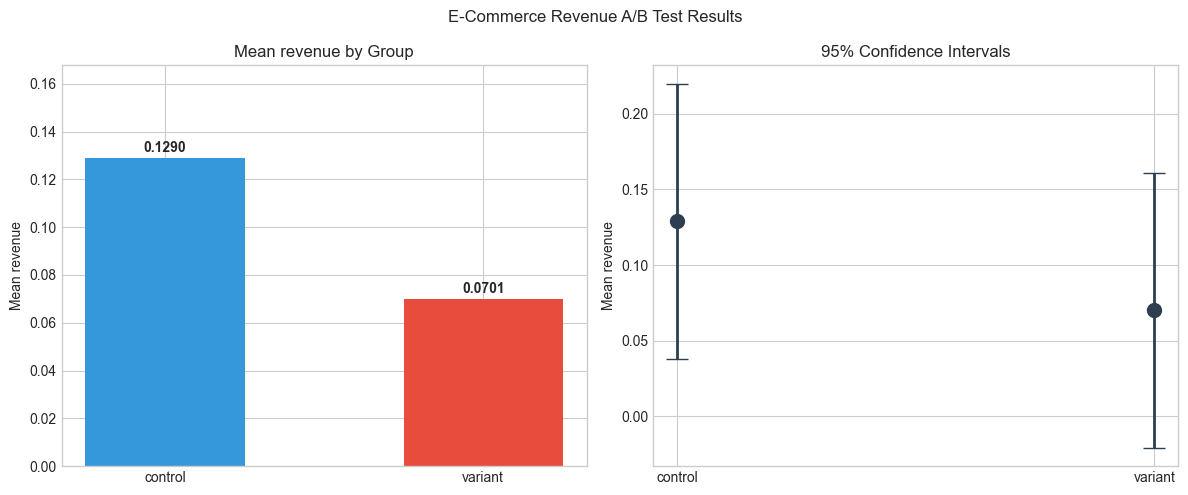

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

group_labels = ['control', 'variant']
metric_means = [mean_a, mean_b]


bars = axes[0].bar(group_labels, metric_means, color=['#3498DB', '#E74C3C'], width=0.5)
axes[0].set_title('Mean revenue by Group') 
axes[0].set_ylabel('Mean revenue') 
axes[0].set_ylim(0, max(metric_means) * 1.3)
for bar, val in zip(bars, metric_means):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(metric_means)*0.02,
                f'{val:.4f}', ha='center', fontweight='bold')


error = (ci_diff[1] - ci_diff[0]) / 2
axes[1].errorbar(group_labels, metric_means, yerr=[error, error],
                fmt='o', capsize=8, linewidth=2, color='#2C3E50', markersize=10)
axes[1].set_title('95% Confidence Intervals')
axes[1].set_ylabel('Mean revenue') 

plt.suptitle('E-Commerce Revenue A/B Test Results') 
plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()


## Visualization — Results Interpretation

### Left Chart: Mean Revenue by Group
The bar chart shows the average revenue per user for each group:

- **Control**: 0.1290
- **Variant**: 0.0701
- **Difference**: -0.0589 (variant is ~45% lower than control)

While the visual gap looks large, bar charts can be misleading — a big visual difference does not mean a statistically significant one.

### Right Chart: 95% Confidence Intervals
The error bars show the range where the true mean is likely to fall.

Key observations:
- Both intervals are **very wide**, meaning there is high uncertainty in both groups
- The intervals **overlap significantly**
- Variant's interval **crosses zero** on the lower end — meaning the true mean could even be negative

When confidence intervals overlap this much, it confirms that the observed difference could easily be due to random chance.

### Conclusion
The charts visually confirm the statistical test result:

| Metric | Value |
|---|---|
| T-test p-value | 0.2037 |
| 95% CI (difference) | (-0.1500, 0.0321) |
| Decision | Fail to reject H0 |

> The variant did not produce a statistically significant change in revenue.  
> The wide confidence intervals and overlapping ranges suggest the dataset may lack the statistical power needed to detect a real effect — if one exists.

In [14]:
print("=" * 50)
print("RESULTS SUMMARY")
print("=" * 50)
print(f"Group A mean : {mean_a:.4f}")
print(f"Group B mean : {mean_b:.4f}")
print(f"Difference : {diff:.4f}")
print(f"T-test p-value : {p_value_t:.4f}")
print(f"Decision : {'Reject H0 ✓' if p_value_t < 0.05 else 'Fail to reject H0 ✗'}")
print("=" * 50)

RESULTS SUMMARY
Group A mean : 0.1290
Group B mean : 0.0701
Difference : -0.0589
T-test p-value : 0.2037
Decision : Fail to reject H0 ✗


## Results Summary

```python
==================================================
RESULTS SUMMARY
==================================================
Group A (control) mean  : 0.1290
Group B (variant)  mean : 0.0701
Difference              : -0.0589
T-test p-value          : 0.2037
Decision                : Fail to reject H0 ✗
==================================================
```

### Interpretation

The variant group shows a lower average revenue (0.0701) compared to control (0.1290), a difference of -0.0589. However, this difference is **not statistically significant**.

| Metric | Value |
|---|---|
| Control mean | 0.1290 |
| Variant mean | 0.0701 |
| Difference | -0.0589 |
| T-test p-value | 0.2037 |
| 95% CI (difference) | (-0.1500, 0.0321) |
| Significance level (α) | 0.05 |
| **Decision** | **Fail to reject H0** |

### Business Decision

`p = 0.2037 > 0.05` and the confidence interval `(-0.1500, 0.0321)` includes zero.

Both the statistical test and the confidence interval agree: **there is not enough evidence to conclude that the variant had any real effect on revenue.**

> ❌ Do not ship the variant based on this result.  
> ✅ Consider increasing the sample size or testing a more impactful change.